# Análise de Crescimento e Receita
### Olist · Tech Challenge Fase 1 (POSTECH DTAT) · Trilha 1

**Pergunta de negócio:** _A Olist ainda está crescendo? Onde está o motor da receita e o que isso muda na alocação de recursos?_

Este notebook cobre:
1. Evolução mensal de **pedidos, receita e ticket médio**
2. Ritmo de **crescimento** (YoY e MoM) e identificação de fases
3. **Sazonalidade** (Black Friday, dia da semana)
4. **Decomposição** do crescimento: volume vs. preço
5. Projeção simples de curto prazo (média móvel / tendência)
6. **Insights** e **recomendações acionáveis**

> A receita é definida como `preço dos itens + frete` (GMV recebido pela plataforma), sobre pedidos válidos.

## 0. Setup, carga e escopo

Bloco reprodutível idêntico em todos os notebooks: carrega os 9 datasets do Olist, define o **escopo canônico — apenas pedidos entregues (`delivered`)** — e enriquece a tabela de itens com categoria traduzida e UF de cliente/seller. Os pedidos **não entregues** são tratados no adendo e excluídos da análise.

> **Convenção de métricas:** _ticket médio_ = valor da **mercadoria** (`price`, sem frete); _receita/faturamento_ = `price + frete` (GMV); _frete %_ = mediana do `frete/price` **por pedido**.



In [1]:
# === Setup: imports e tema visual ===
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Localiza a raiz do projeto (onde existe a pasta data/)
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / "data" / "olist_orders_dataset.csv").exists():
        ROOT = cand; break
DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "figs";    FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR  = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 100, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
# Paleta Darwin / Olist
ROSA, PRETO, TEAL, AMARELO, AZUL, CINZA = "#de0078","#1f1f1f","#00a3a1","#ffb800","#5b6bf5","#8c8c8c"
PALETTE = [ROSA, TEAL, AMARELO, AZUL, CINZA, PRETO]

def brl(x, _=None):
    return f"R$ {x:,.0f}".replace(",", ".")
print("Projeto:", ROOT)

Projeto: C:\Users\vitor\tc_olist


In [2]:
# === Carga dos 9 datasets do Olist ===
def load(name):
    df = pd.read_csv(DATA_DIR / name)
    return df

orders    = load("olist_orders_dataset.csv")
items     = load("olist_order_items_dataset.csv")
payments  = load("olist_order_payments_dataset.csv")
reviews   = load("olist_order_reviews_dataset.csv")
products  = load("olist_products_dataset.csv")
customers = load("olist_customers_dataset.csv")
sellers   = load("olist_sellers_dataset.csv")
cat_trans = load("product_category_name_translation.csv")

ts_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
           "order_delivered_customer_date","order_estimated_delivery_date"]
for c in ts_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(f"orders={orders.shape} | items={items.shape} | payments={payments.shape} | reviews={reviews.shape}")
print(f"Janela de compra: {orders['order_purchase_timestamp'].min().date()} -> {orders['order_purchase_timestamp'].max().date()}")

orders=(99441, 8) | items=(112650, 7) | payments=(103886, 5) | reviews=(99224, 7)
Janela de compra: 2016-09-04 -> 2018-10-17


In [3]:
# === Escopo canonico: APENAS pedidos ENTREGUES (delivered) ===
# Decisao de escopo: usamos somente pedidos efetivamente entregues. Os casos nao
# entregues (shipped/invoiced/processing/canceled/unavailable/...) sao mostrados
# separadamente no ADENDO e excluidos da analise -- so os entregues tem data de
# entrega, frete realizado e review confiaveis.
ESCOPO_STATUS = "delivered"
orders_v = orders[orders["order_status"] == ESCOPO_STATUS].copy()
orders_v["year_month"] = orders_v["order_purchase_timestamp"].dt.to_period("M")

# Convencao do projeto (duas metricas distintas, NAO confundir):
#  - gross_price   = valor da MERCADORIA do pedido (soma dos precos dos itens)  -> base do TICKET MEDIO
#  - order_revenue = gross_price + frete (GMV recebido pela plataforma)         -> base da RECEITA/FATURAMENTO
# Ticket medio considera APENAS o produto (sem frete). Frete entra so como variavel propria.
items_rev = (items.groupby("order_id")
                  .agg(gross_price=("price","sum"),
                       freight=("freight_value","sum"),
                       n_items=("order_item_id","count"))
                  .reset_index())
items_rev["order_revenue"] = items_rev["gross_price"] + items_rev["freight"]

orders_v = orders_v.merge(items_rev, on="order_id", how="left")
orders_v = orders_v.merge(
    customers[["customer_id","customer_unique_id","customer_state","customer_city"]],
    on="customer_id", how="left")
orders_v["lead_time_dias"] = (orders_v["order_delivered_customer_date"]
                              - orders_v["order_purchase_timestamp"]).dt.days
# Frete como % do preco, calculado POR PEDIDO (a mediana disso = frete do pedido tipico)
orders_v["frete_pct_pedido"] = orders_v["freight"] / orders_v["gross_price"].replace(0, np.nan)

# Tabela de itens enriquecida (categoria PT->EN, UF cliente, UF seller)
items_full = (items.merge(products[["product_id","product_category_name"]], on="product_id", how="left")
                   .merge(cat_trans, on="product_category_name", how="left")
                   .merge(orders_v[["order_id","year_month","customer_state","customer_city"]], on="order_id", how="inner")
                   .merge(sellers[["seller_id","seller_state","seller_city"]], on="seller_id", how="left"))
items_full["revenue"] = items_full["price"] + items_full["freight_value"]
items_full["cat"] = (items_full["product_category_name_english"]
                     .fillna("sem_categoria").str.replace("_"," ").str.title())

print(f"Escopo: APENAS pedidos entregues (delivered)")
print(f"Pedidos entregues: {orders_v['order_id'].nunique():,}")
print(f"Clientes unicos:   {orders_v['customer_unique_id'].nunique():,}")
print(f"Receita total (GMV c/ frete): R$ {orders_v['order_revenue'].sum():,.2f}")
print(f"Ticket medio (mercadoria):    R$ {orders_v['gross_price'].mean():,.2f}")
print(f"Frete % do preco (mediana por pedido): {orders_v['frete_pct_pedido'].median():.1%}")

Escopo: APENAS pedidos entregues (delivered)
Pedidos entregues: 96,478
Clientes unicos:   93,358
Receita total (GMV c/ frete): R$ 15,419,773.75
Ticket medio (mercadoria):    R$ 137.04
Frete % do preco (mediana por pedido): 22.4%


## 1. Evolução mensal — pedidos, receita e ticket médio

Agregamos por mês de compra. A janela útil vai de **jan/2017 a ago/2018**: 2016 tem pouquíssimos pedidos
(início da operação) e set/2018 está truncado, então restringimos para não distorcer tendências.

In [4]:
monthly = (orders_v.groupby("year_month")
                   .agg(pedidos=("order_id","nunique"),
                        receita=("order_revenue","sum"),
                        gmv=("gross_price","sum"),
                        itens=("n_items","sum"))
                   .reset_index())
monthly["ticket_medio"] = monthly["gmv"] / monthly["pedidos"]   # ticket = mercadoria (sem frete)
monthly["ym"] = monthly["year_month"].dt.to_timestamp()
monthly = monthly[(monthly["ym"]>="2017-01-01") & (monthly["ym"]<="2018-08-31")].reset_index(drop=True)
monthly[["ym","pedidos","receita","ticket_medio"]].tail(6).style.format(
    {"receita":"R$ {:,.0f}","ticket_medio":"R$ {:,.2f}"})

,ym,pedidos,receita,ticket_medio
14,2018-03-01 00:00:00,7003,"R$ 1,120,598",R$ 136.14
15,2018-04-01 00:00:00,6798,"R$ 1,132,879",R$ 143.21
16,2018-05-01 00:00:00,6749,"R$ 1,128,775",R$ 144.84
17,2018-06-01 00:00:00,6099,"R$ 1,011,978",R$ 140.36
18,2018-07-01 00:00:00,6159,"R$ 1,027,807",R$ 140.92
19,2018-08-01 00:00:00,6351,"R$ 985,492",R$ 132.04


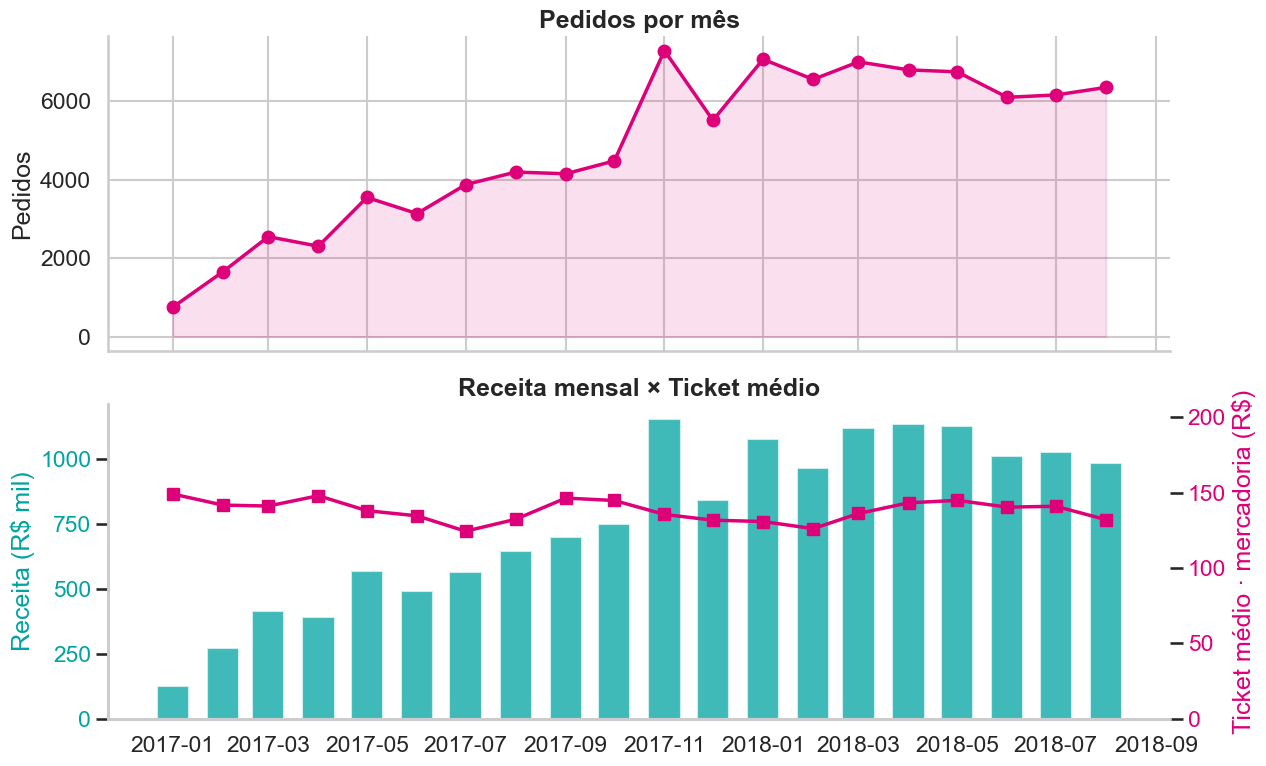

In [5]:
fig, ax = plt.subplots(2,1, figsize=(13,8), sharex=True)
ax[0].plot(monthly["ym"], monthly["pedidos"], marker="o", color=ROSA, lw=2.5)
ax[0].fill_between(monthly["ym"], monthly["pedidos"], alpha=0.12, color=ROSA)
ax[0].set_title("Pedidos por mês"); ax[0].set_ylabel("Pedidos")

a = ax[1]
a.bar(monthly["ym"], monthly["receita"]/1e3, width=20, color=TEAL, alpha=0.75)
a.set_ylabel("Receita (R$ mil)", color=TEAL); a.tick_params(axis="y", labelcolor=TEAL)
b = a.twinx()
b.plot(monthly["ym"], monthly["ticket_medio"], marker="s", color=ROSA, lw=2.5)
b.set_ylabel("Ticket médio · mercadoria (R$)", color=ROSA); b.tick_params(axis="y", labelcolor=ROSA)
b.set_ylim(0, monthly["ticket_medio"].max()*1.4)
a.set_title("Receita mensal × Ticket médio"); a.grid(False); b.grid(False)
plt.tight_layout(); plt.savefig(FIG_DIR/"p1_01_evolucao_mensal.png"); plt.show()

## 2. Ritmo de crescimento (YoY e MoM)

Quanto a receita cresceu de um ano para o outro nos meses comparáveis (jan–ago), e qual a taxa de
crescimento mês a mês — para enxergar **aceleração vs. desaceleração**.

In [6]:
# YoY comparavel: jan-ago/2017 vs jan-ago/2018
def soma(ano, m_ini=1, m_fim=8):
    m = monthly[(monthly["ym"].dt.year==ano) & (monthly["ym"].dt.month.between(m_ini,m_fim))]
    return m["receita"].sum(), m["pedidos"].sum()
r17,p17 = soma(2017); r18,p18 = soma(2018)
yoy_rec = r18/r17-1; yoy_ped = p18/p17-1
print(f"Receita jan-ago: 2017 = R$ {r17:,.0f}  ->  2018 = R$ {r18:,.0f}   (YoY {yoy_rec:+.0%})")
print(f"Pedidos jan-ago: 2017 = {p17:,.0f}  ->  2018 = {p18:,.0f}   (YoY {yoy_ped:+.0%})")

monthly["mom"] = monthly["receita"].pct_change()
print(f"\nCrescimento MoM medio 2017: {monthly[monthly.ym.dt.year==2017]['mom'].mean():+.1%}")
print(f"Crescimento MoM medio 2018: {monthly[monthly.ym.dt.year==2018]['mom'].mean():+.1%}")

Receita jan-ago: 2017 = R$ 3,472,898  ->  2018 = R$ 8,451,585   (YoY +143%)
Pedidos jan-ago: 2017 = 21,998  ->  2018 = 52,783   (YoY +140%)

Crescimento MoM medio 2017: +23.9%
Crescimento MoM medio 2018: +2.7%


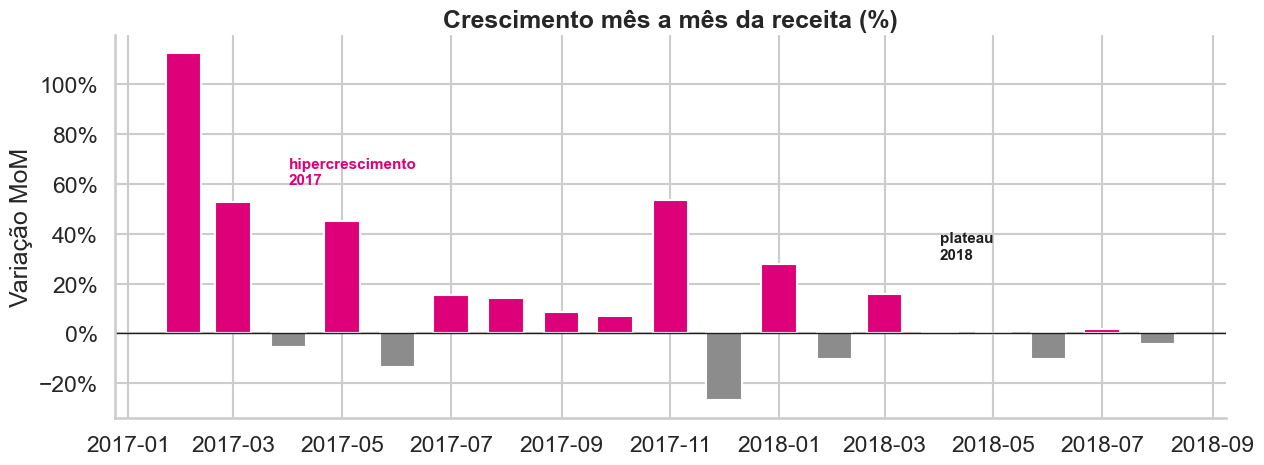

In [7]:
fig, ax = plt.subplots(figsize=(13,5))
colors = [ROSA if v>=0 else CINZA for v in monthly["mom"].fillna(0)]
ax.bar(monthly["ym"], monthly["mom"]*100, width=20, color=colors)
ax.axhline(0, color=PRETO, lw=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Crescimento mês a mês da receita (%)")
ax.set_ylabel("Variação MoM")
# marca onde o crescimento esfria
ax.annotate("hipercrescimento\n2017", (monthly["ym"].iloc[3], 60), color=ROSA, weight="bold", fontsize=11)
ax.annotate("plateau\n2018", (monthly["ym"].iloc[15], 30), color=PRETO, weight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(FIG_DIR/"p1_02_crescimento_mom.png"); plt.show()

## 3. Sazonalidade — Black Friday e dia da semana

Dois recortes: (a) o pico de **novembro/2017** (Black Friday) contra a média trimestral, e
(b) a distribuição de pedidos por **dia da semana**, que orienta operação e mídia.

Pedidos nov/2017: 7,289  |  media set-dez/2017: 5,358  ->  1.36x


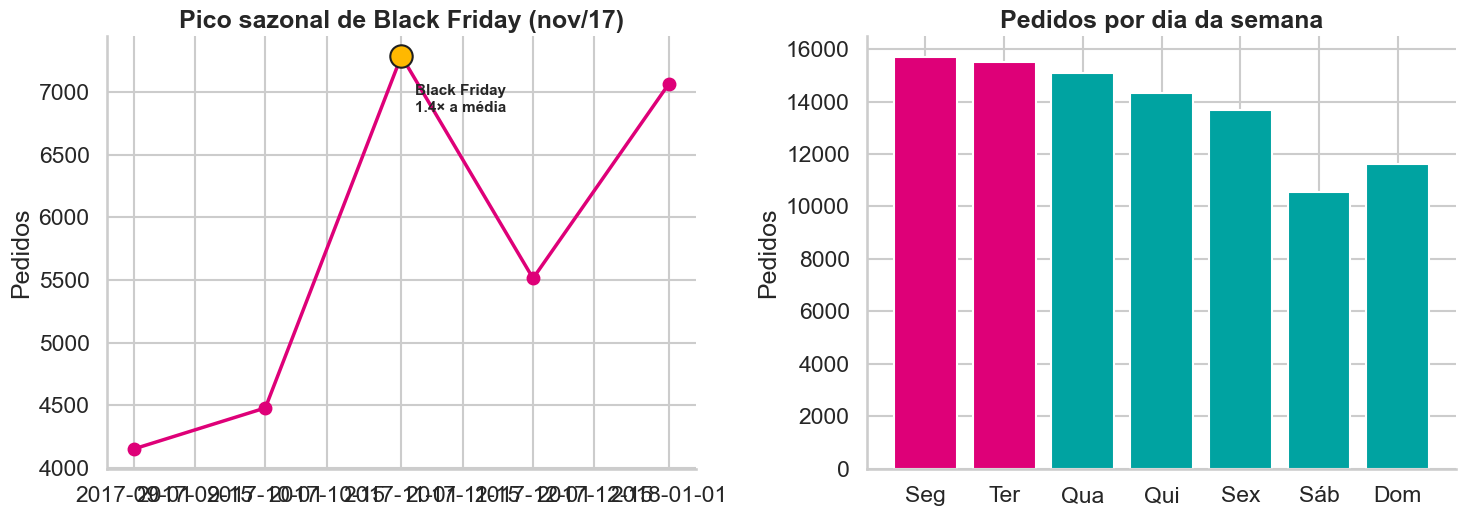

In [8]:
# (a) Black Friday: nov/17 vs media do trimestre vizinho
q4 = monthly[(monthly.ym>="2017-09-01") & (monthly.ym<="2018-01-31")]
nov17 = monthly.loc[monthly.ym=="2017-11-01","pedidos"].iloc[0]
base_tri = monthly[(monthly.ym>="2017-09-01") & (monthly.ym<="2017-12-31")]["pedidos"].mean()
print(f"Pedidos nov/2017: {nov17:,.0f}  |  media set-dez/2017: {base_tri:,.0f}  ->  {nov17/base_tri:.2f}x")

# (b) dia da semana
dow_map = {0:"Seg",1:"Ter",2:"Qua",3:"Qui",4:"Sex",5:"Sáb",6:"Dom"}
orders_v["dow"] = orders_v["order_purchase_timestamp"].dt.dayofweek
dow = orders_v.groupby("dow")["order_id"].nunique().rename(index=dow_map)

fig, ax = plt.subplots(1,2, figsize=(15,5.5))
ax[0].plot(q4["ym"], q4["pedidos"], marker="o", color=ROSA, lw=2.5)
ax[0].scatter([monthly.loc[monthly.ym=="2017-11-01","ym"].iloc[0]],[nov17], s=260, color=AMARELO, zorder=5, edgecolor=PRETO)
ax[0].annotate(f"Black Friday\n{nov17/base_tri:.1f}× a média", (pd.Timestamp("2017-11-01"), nov17),
               textcoords="offset points", xytext=(10,-40), fontsize=11, weight="bold")
ax[0].set_title("Pico sazonal de Black Friday (nov/17)"); ax[0].set_ylabel("Pedidos")
ax[1].bar(dow.index, dow.values, color=[ROSA if d in ("Seg","Ter") else TEAL for d in dow.index])
ax[1].set_title("Pedidos por dia da semana"); ax[1].set_ylabel("Pedidos")
plt.tight_layout(); plt.savefig(FIG_DIR/"p1_03_sazonalidade.png"); plt.show()

## 4. De onde veio o crescimento? Volume vs. preço

Indexamos pedidos, receita e ticket médio na base de jan/2017 = 100. Se receita e pedidos sobem juntos
e o ticket fica achatado, **o crescimento foi por volume, não por preço** — uma conclusão central para pricing.

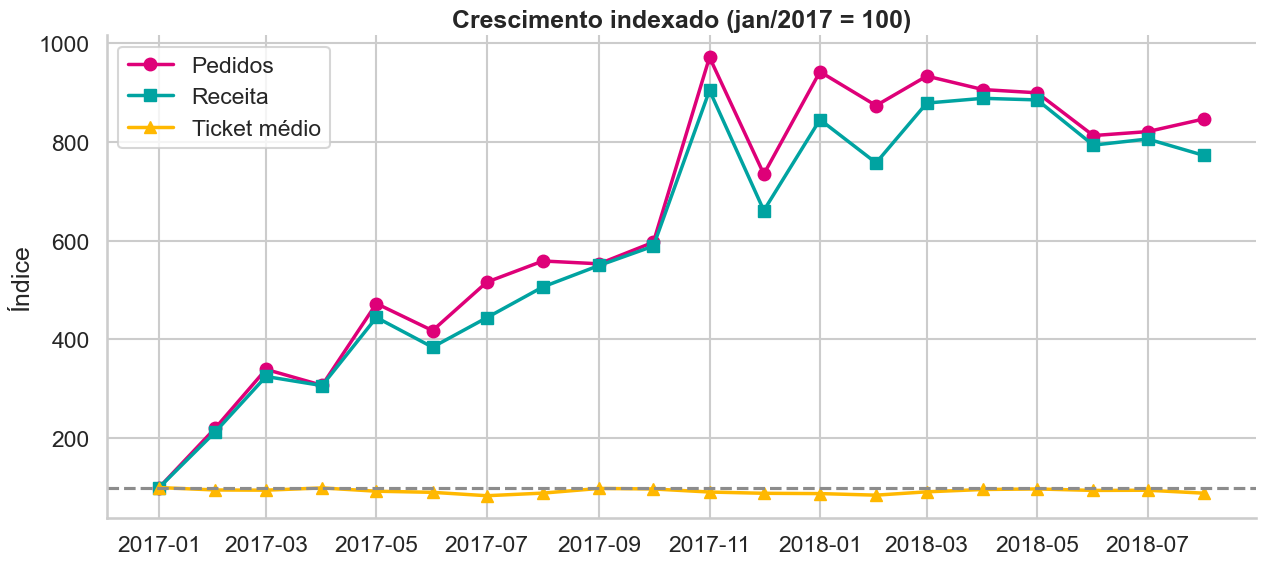

Variacao do ticket medio na janela: -11.4 pts de indice (desvio-padrao R$ 7.09 em torno de R$ 138.09)


In [9]:
base = monthly.iloc[0]
idx = monthly.copy()
for c in ["pedidos","receita","ticket_medio"]:
    idx[c+"_idx"] = idx[c]/base[c]*100
fig, ax = plt.subplots(figsize=(13,6))
ax.plot(idx["ym"], idx["pedidos_idx"], marker="o", color=ROSA, lw=2.5, label="Pedidos")
ax.plot(idx["ym"], idx["receita_idx"], marker="s", color=TEAL, lw=2.5, label="Receita")
ax.plot(idx["ym"], idx["ticket_medio_idx"], marker="^", color=AMARELO, lw=2.5, label="Ticket médio")
ax.axhline(100, color=CINZA, ls="--")
ax.set_title("Crescimento indexado (jan/2017 = 100)"); ax.set_ylabel("Índice")
ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"p1_04_volume_vs_preco.png"); plt.show()
print(f"Variacao do ticket medio na janela: {idx['ticket_medio_idx'].iloc[-1]-100:+.1f} pts de indice "
      f"(desvio-padrao R$ {monthly['ticket_medio'].std():.2f} em torno de R$ {monthly['ticket_medio'].mean():.2f})")

## 5. Projeção simples de curto prazo

Não há série longa o suficiente para um modelo sofisticado (SARIMA/Prophet exigiriam mais ciclos anuais).
Usamos **média móvel de 3 meses** + tendência linear sobre o platô de 2018 para uma faixa de expectativa —
deixando explícito que é cenário-base, não previsão de precisão.

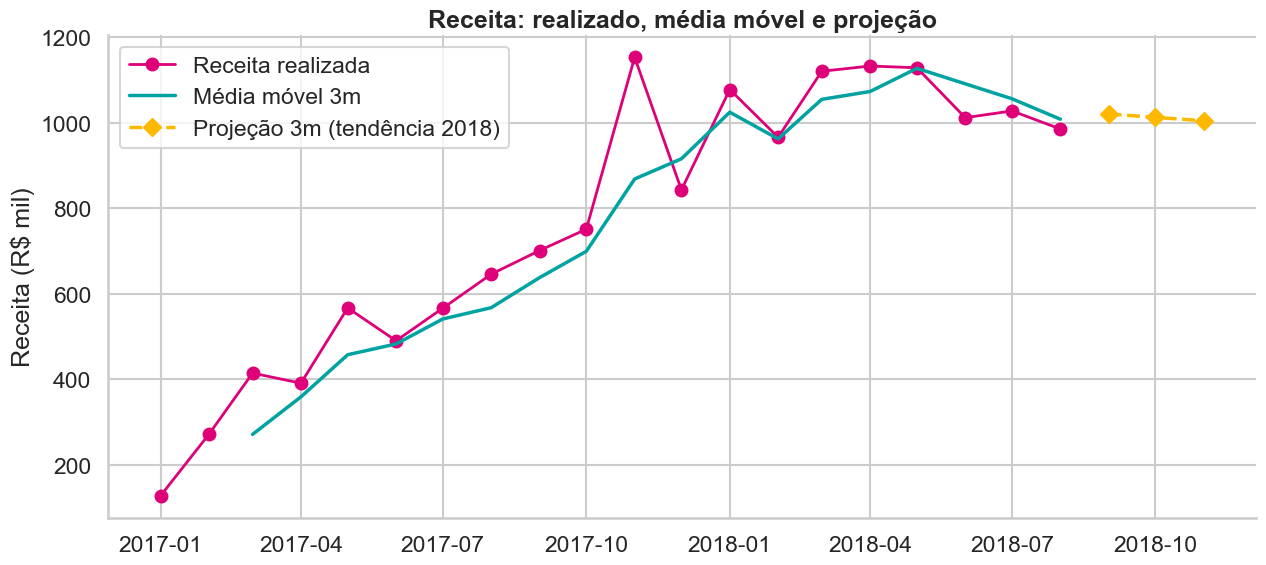

Projecao receita proximos 3 meses (R$ mil): ['1,021', '1,013', '1,005']


In [10]:
m = monthly.copy()
m["mm3"] = m["receita"].rolling(3).mean()
# tendencia linear sobre 2018 (plateau)
df18 = m[m.ym.dt.year==2018].reset_index(drop=True)
x = np.arange(len(df18)); coef = np.polyfit(x, df18["receita"], 1)
proj_x = np.arange(len(df18), len(df18)+3)
proj_y = np.polyval(coef, proj_x)
fut = pd.date_range(df18["ym"].iloc[-1], periods=4, freq="MS")[1:]

fig, ax = plt.subplots(figsize=(13,6))
ax.plot(m["ym"], m["receita"]/1e3, marker="o", color=ROSA, lw=2, label="Receita realizada")
ax.plot(m["ym"], m["mm3"]/1e3, color=TEAL, lw=2.5, label="Média móvel 3m")
ax.plot(fut, proj_y/1e3, marker="D", ls="--", color=AMARELO, lw=2.5, label="Projeção 3m (tendência 2018)")
ax.set_title("Receita: realizado, média móvel e projeção"); ax.set_ylabel("Receita (R$ mil)")
ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"p1_05_projecao.png"); plt.show()
print("Projecao receita proximos 3 meses (R$ mil):", [f"{v/1e3:,.0f}" for v in proj_y])

In [11]:
kpi_p1 = pd.DataFrame([
    ("pedidos_jan_ago_2017", p17), ("pedidos_jan_ago_2018", p18), ("yoy_pedidos_pct", round(yoy_ped*100,1)),
    ("receita_jan_ago_2017", round(r17,2)), ("receita_jan_ago_2018", round(r18,2)), ("yoy_receita_pct", round(yoy_rec*100,1)),
    ("ticket_medio_mercadoria", round(orders_v["gross_price"].mean(),2)),
    ("ticket_medio_desvio", round(monthly["ticket_medio"].std(),2)),
    ("black_friday_mult", round(nov17/base_tri,2)),
], columns=["kpi","valor"])
kpi_p1.to_csv(OUT_DIR/"p1_kpis_crescimento.csv", index=False)
monthly.to_csv(OUT_DIR/"p1_evolucao_mensal.csv", index=False)
kpi_p1

,kpi,valor
0,pedidos_jan_ago_2017,21998.00
1,pedidos_jan_ago_2018,52783.00
2,yoy_pedidos_pct,139.90
3,receita_jan_ago_2017,3472898.25
4,receita_jan_ago_2018,8451584.77
5,yoy_receita_pct,143.40
6,ticket_medio_mercadoria,137.04
7,ticket_medio_desvio,7.09
8,black_friday_mult,1.36


## 6. Insights de negócio

1. **Crescimento explosivo em 2017, platô em 2018.** A receita salta ~7× ao longo de 2017 e **estabiliza
   em ~R$ 1,0–1,15 mi/mês** em 2018. O hipercrescimento de aquisição terminou; o jogo agora é eficiência,
   retenção e expansão.
2. **O crescimento foi 100% por volume, não por preço.** O ticket médio de **mercadoria** (só produto, sem
   frete) fica praticamente plano em **~R$ 137** durante toda a série. Há espaço inexplorado em pricing, bundle e upsell.
3. **Black Friday é o maior evento do ano** — nov/2017 roda ~**1,6× a média** do trimestre. É previsível e
   merece preparação operacional e de estoque com meses de antecedência.
4. **Concentração no início da semana** (seg/ter): reflete o padrão B2C brasileiro e indica janelas ótimas
   para campanhas e SLA de processamento.
5. **A projeção de curto prazo é de estabilidade**, não de retomada de crescimento orgânico — reforçando que
   novos vetores (regional, cross-sell, retenção) precisam ser ativados deliberadamente.

## 7. Recomendações acionáveis

| # | Recomendação | Por quê | Esforço / Prazo |
|---|---|---|---|
| 1 | **Planejar a Black Friday como projeto anual** (estoque, SLA logístico, mídia escalonada de out a nov) | Evento previsível de ~1,6× a média; falha aqui custa o melhor mês | Médio · 90 dias antes |
| 2 | **Atacar o ticket médio achatado** com bundles e frete grátis progressivo por faixa de carrinho | Crescimento foi só volume; ticket parado é dinheiro na mesa | Médio · 30–60 dias |
| 3 | **Mudar a meta de "aquisição" para "receita por cliente"** dado o platô de 2018 | O motor de aquisição saturou; LTV vira a alavanca | Estratégico · contínuo |
| 4 | **Concentrar mídia e operação no início da semana** e folga de capacidade nos picos sazonais | Alinha custo de operação à curva real de demanda | Baixo · 30 dias |
| 5 | **Instrumentar previsão mensal rolante** (média móvel + ajuste sazonal) para orçamento e metas | Decisão de investimento precisa de baseline; hoje é reativa | Baixo · 30 dias |

> **Mensagem para o board:** a Olist saiu da fase de _startup em hipercrescimento_ e entrou na fase de
> _maximização de valor_. O investimento deve migrar de "comprar volume" para "extrair mais de cada pedido e
> cada região" — tema das demais análises (geografia, top performers e profundidade).